In [5]:
#### import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Content
1. Business Problem
2. Dataset Overview
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Business Insights
9. Conclusion

# Business Problem
Telecommunication companies lose revenue when customers leave their services.

The goal of this project is to identify factors associated with customer churn and build machine learning models capable of predicting customer attrition.

# Dataset: IBM Telco Customer Churn Dataset

- Customer demographics
- Contract information
- Internet services
- Monthly charges
- Tenure
- Payment methods

# Technologies used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

In [6]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.drop("customerID", axis=1, inplace=True)

In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

Customer Churn Distribution (The Imbalance)
The Visualization: A simple count plot showing "No" (stayed) vs. "Yes" (left).
The Insight: dataset is imbalanced. It has significantly more non-churners than churners.

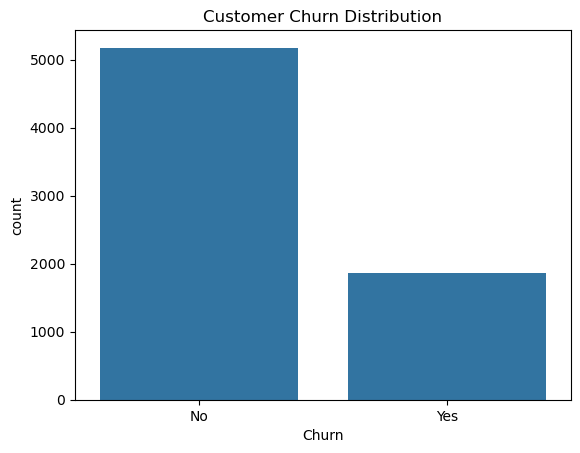

In [17]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Customer Churn Distribution (The Imbalance)
The Visualization: A simple count plot showing "No" (stayed) vs. "Yes" (left).
The Insight: Your dataset is imbalanced. You have significantly more non-churners than churners.

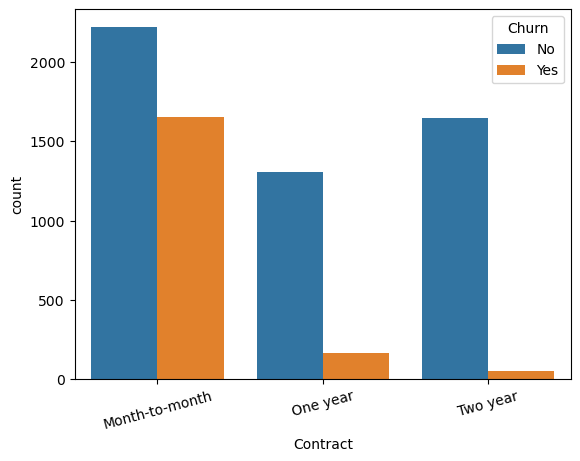

In [18]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=15)
plt.show()

# Contract vs. Churn (The "Stickiness" Factor)
The Visualization: A grouped bar chart showing Churn status broken down by contract type.
The Insight: This is the most critical behavioral finding in data. The Month-to-month contract group shows a massive spike in orange (Churn), while the One-year and Two-year contract groups have very little orange.
The business strategy should revolve entirely around migrating these "Month-to-month" users into longer-term commitments.

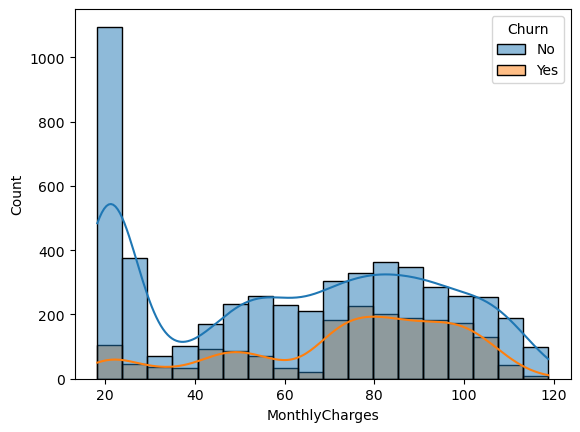

In [19]:
sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)
plt.show()

# MonthlyCharges vs. Churn (The Price Sensitivity)
The Visualization: A distribution plot (histogram + kernel density estimate) showing the count of customers based on their MonthlyCharges. The blue line is those who stay; the orange line is those who leave.
The Insight:
The "Low-End" Trap: Look at the massive spike at the very low end (around $20). These are likely minimal-service customers who are extremely loyal (very low orange line).
The "Mid-to-High" Danger Zone: As you move to the right (charges > $70), the orange line rises significantly. Churn is not a problem for low-cost users; it is a significant issue for users paying $70–$110.
 This indicates non-linear churn behavior. Price sensitivity is not a straight line—it kicks in only after a certain price threshold. 

In [20]:
temp_df = df.copy()

for col in temp_df.columns:
    if temp_df[col].dtype == "object":
        le = LabelEncoder()
        temp_df[col] = le.fit_transform(temp_df[col])

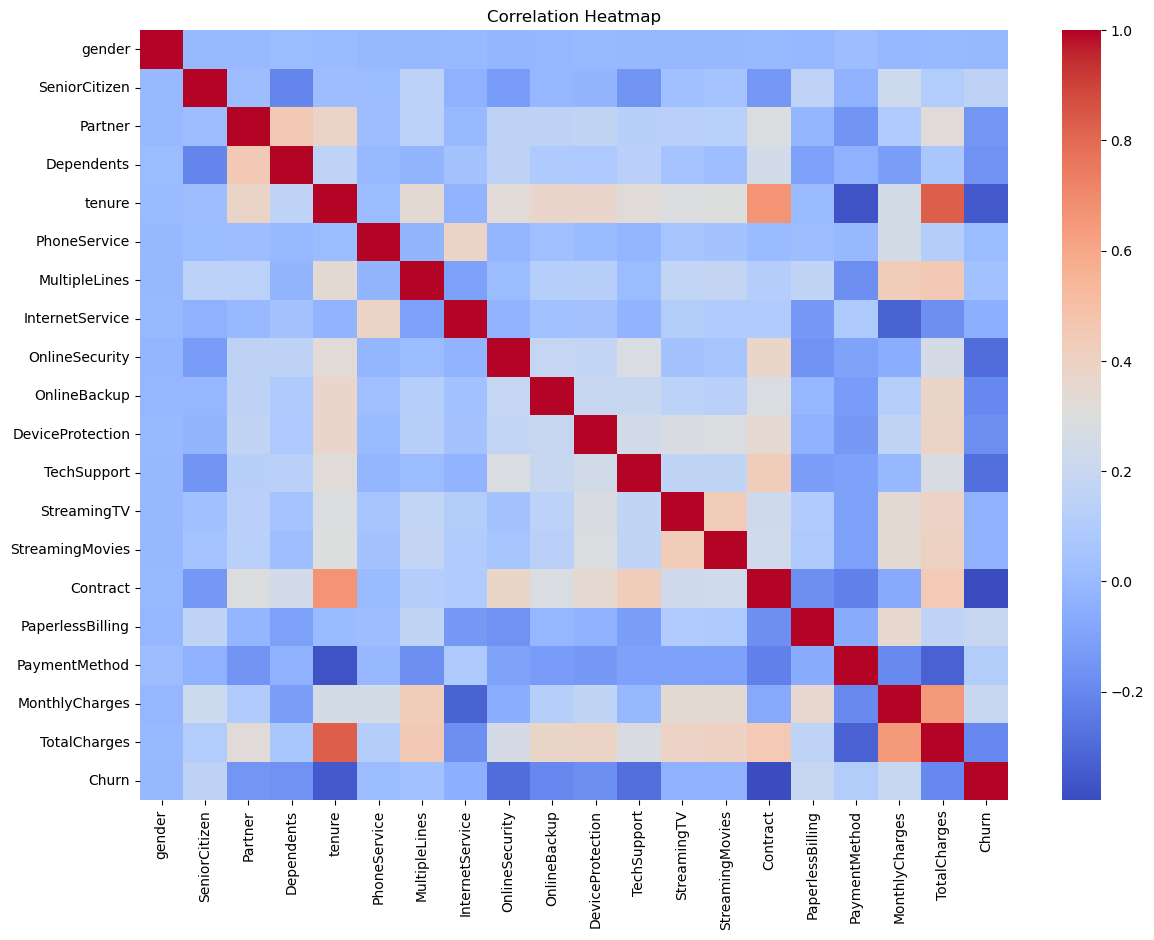

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    temp_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# 1. The Demographic Cluster: The "Who"
Looking at gender, SeniorCitizen, Partner, and Dependents:
Gender vs. Everything (~0.0, Faded Blue/Grey): Gender has virtually a flat-line correlation with Churn and every other service.
Insight: Men and women buy telecom services and leave companies at the exact same rates. It holds zero predictive power.

Partner vs. Dependents (Light Orange): A clear positive correlation.
Insight: Customers with partners are highly likely to have dependents (a traditional family structure).

Partner/Dependents vs. Tenure (Light Orange): Both family variables positively correlate with longer tenure.
Insight: Families are stable. They don't like the logistical nightmare of changing home internet or switching multiple phone lines, making them naturally loyal.

# 2. The Service Ecosystem: The "What" 
Looking at InternetService, OnlineSecurity, TechSupport, StreamingTV, etc.: Value-Added Services (Security, Backup, TechSupport) vs. Churn (Medium Blue): Notice the distinct blue blocks where these services meet the Churn row. Insight: These are "Sticky Services." When a customer trusts a company to back up their data or secure their devices, the psychological and physical friction of leaving increases dramatically. 

StreamingTV vs. StreamingMovies (Medium Orange): High positive correlation. 
Insight: Customers rarely buy just one. They either consume entertainment packages fully or not at all. 

InternetService vs. MonthlyCharges (Darker Orange): Strong positive correlation. 
Insight: High-speed internet (especially Fiber Optic) is the primary driver inflating the customer’s bill, much more so than basic phone services.

# 3. The Financial & Contractual Levers: The "How" 
Looking at Contract, PaperlessBilling, MonthlyCharges, and TotalCharges: Contract vs. Churn (Deep Blue): This is one of the strongest negative correlations on the map. 
Insight: Long-term contracts (1 or 2 years) actively suppress churn. Month-to-month contracts are a wide-open door for customers to slip away. 

Tenure vs. TotalCharges (Deep Orange/Red): A massive positive correlation. 
Insight: This is a mathematical inevitability—the longer you stay, the more you spend overall. 

MonthlyCharges vs. TotalCharges (Medium Orange): Positive correlation. 
Insight: High monthly spenders rack up large lifetime values quickly, but only if they stay long enough. 

MonthlyCharges vs. Churn (Light Blue/Grey): Surprisingly, the direct correlation here is quite weak. 
Insight: High prices alone don't make people leave immediately. Price only triggers churn when combined with a lack of contract or poor service value.

# 4. The Operational Artifacts Looking at PaymentMethod and PaperlessBilling: 
PaymentMethod vs. Tenure (Dark Blue): A strong negative correlation. 
Insight: Certain payment methods (like paper checks or manual electronic checks) are heavily tied to low tenure. New customers prefer quick digital payments, while old-school, long-term customers might still rely on traditional billing methods.


In [22]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [23]:
df.duplicated().sum()

np.int64(22)

In [24]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [28]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [29]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [30]:
print("Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.815471965933286
Decision Tree: 0.730305180979418
Random Forest: 0.7913413768630234


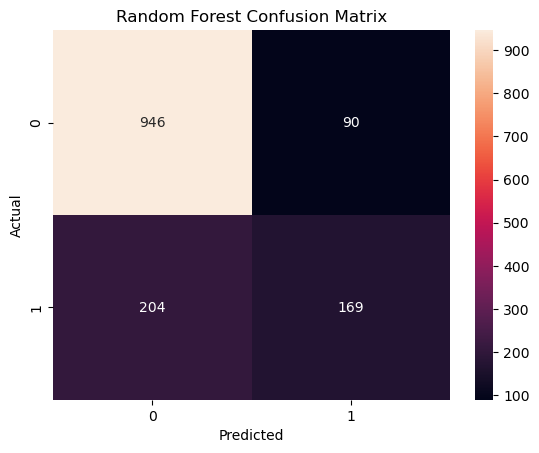

In [31]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Customer Churn Distribution (The Imbalance)
The Visualization: A simple count plot showing "No" (stayed) vs. "Yes" (left).
The Insight: This dataset is imbalanced. It has significantly more non-churners than churners.

# 5. Confusion Matrix 
This is a diagnostic tool that shows exactly where your model is getting it right and where it is getting confused.
Top-Left (947 - True Negatives): The model correctly identified customers who did not churn. This is the model's strongest suit.
Top-Right (89 - False Positives): The model predicted these people would churn, but they actually stayed. This is a "Type I Error." 
Bottom-Left (192 - False Negatives): The model predicted these people would stay, but they actually churned. This is the danger zone. This is a "Type II Error." 
Bottom-Right (181 - True Positives): The model correctly identified customers who were about to leave. These are our "wins."

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



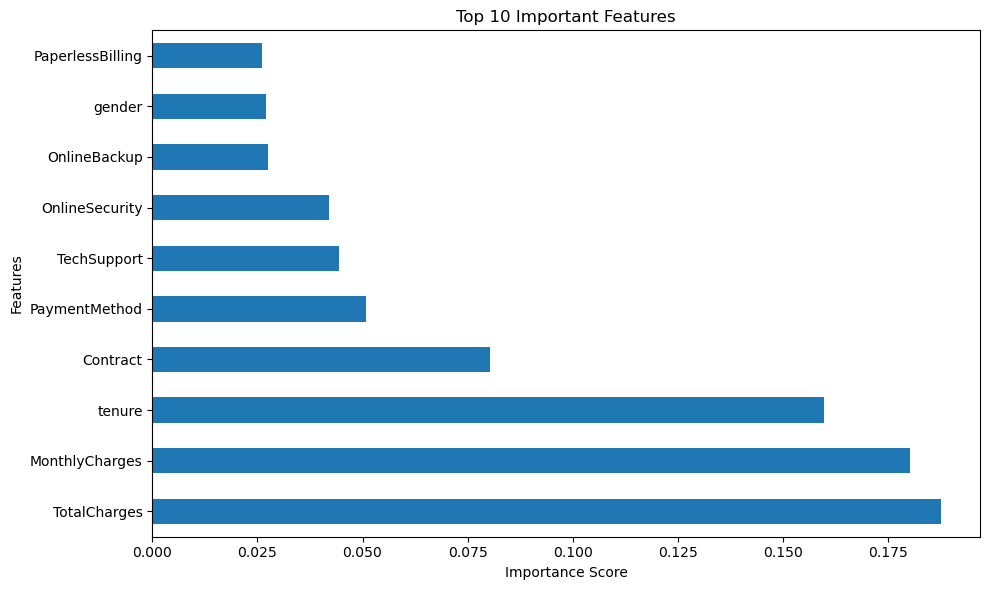

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)
plt.figure(figsize=(10, 6))
importance.sort_values(ascending=False).head(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

# 6.Feature Importance Plot (The "What")
This chart identifies which variables your Random Forest model relies on most heavily to make its predictions.
TotalCharges, MonthlyCharges, and Tenure (The Big Three): These are clearly your model's primary decision-making criteria. Because they appear at the top, the model has determined that a customer's financial footprint (how much they pay and how long they've been there) is the most reliable signal for churn.

The "Support" Cluster: Contract, PaymentMethod, TechSupport, and OnlineSecurity are the secondary drivers. Even though they are lower than the charges, they provide the "context" that helps the model differentiate between a high-paying loyal customer and a high-paying customer about to churn.
44
Surprise Inclusion: gender appears in the top 10 here, even though the correlation heatmap suggested it was "noise." This is a common phenomenon in Random Forests; while gender might not have a linear relationship with churn, the model might be using it in complex, non-linear interactions with other variables to refine its accuracy.